<a href="https://colab.research.google.com/github/EsatovinVictoria/ML_Semester5_EsatovinEbenhaezerVictoria/blob/main/Pertemuan_4/JS04_Klasterisasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum 1

## KMeans

In [167]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [168]:
#Persiapan data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('/content/drive/MyDrive/Iris.csv')

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [169]:
#Seleksi Fitur
X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


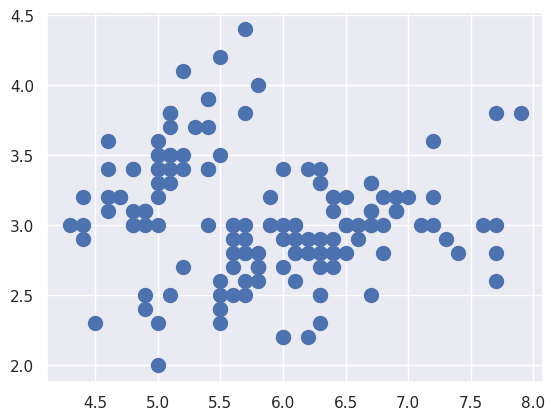

In [170]:
# Plot Data
# Karena data 4 dimensi, maka akan kita coba
# plot cluster berdasarkan Sepal Length dan Sepal Width  saja

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100)

In [171]:
# Buat Model KMeans
# Kali ini kita coba menggunakan k=2 - anggap saja kita tidak tahu jumlah label ada 3 :)

from sklearn.cluster import KMeans

# Inisiasi obyek KMeans
cl_kmeans = KMeans(n_clusters=2)

# Fit dan predict model
y_kmeans = cl_kmeans.fit_predict(X)

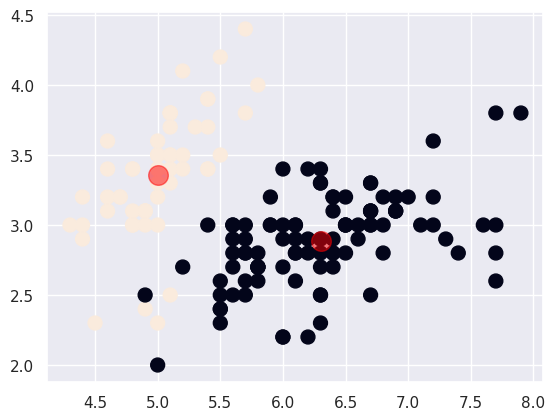

In [172]:
# Plot hasi cluster berdasarkan Sepal Length dan Sepal Width
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100, c=y_kmeans)

# Plot centroid
centers = cl_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)

In [173]:
# Cek Nilai SSE
print(f'Nilai SSE: {cl_kmeans.inertia_}')

Nilai SSE: 152.36870647733915


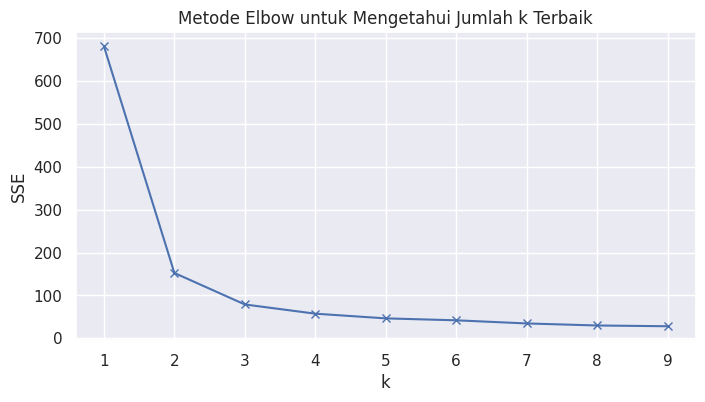

In [174]:
# Implementasi Metode Elbow

# List nilai SSE
sse = []

# Cari k terbaik dari 1-10
K = range(1,10)

# Cek nilai SSE setiap k
for k in K:
 kmeanModel = KMeans(n_clusters=k)
 kmeanModel.fit(X)
 sse.append(kmeanModel.inertia_)


# Plotting the distortions
plt.figure(figsize=(8,4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

In [175]:
# Cek Nilai SSE setiap k
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

k=1; SSE=680.8243999999996
k=2; SSE=152.36870647733915
k=3; SSE=78.94506582597728
k=4; SSE=57.4732732654949
k=5; SSE=46.535582051282034
k=6; SSE=42.02656666666665
k=7; SSE=34.721892109500814
k=8; SSE=29.95408642103723
k=9; SSE=28.177830781939484


# Praktikum 2

In [176]:
#Import library
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np

## Pengantar k-Means

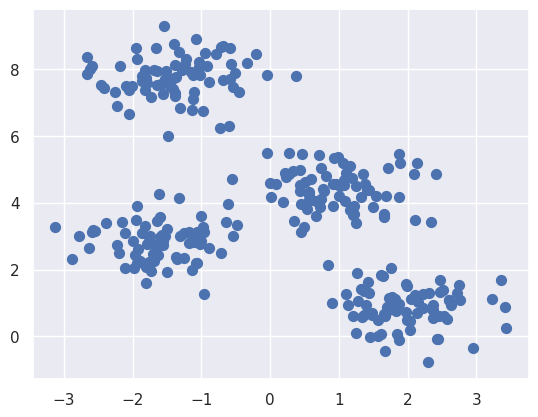

In [177]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);

In [178]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

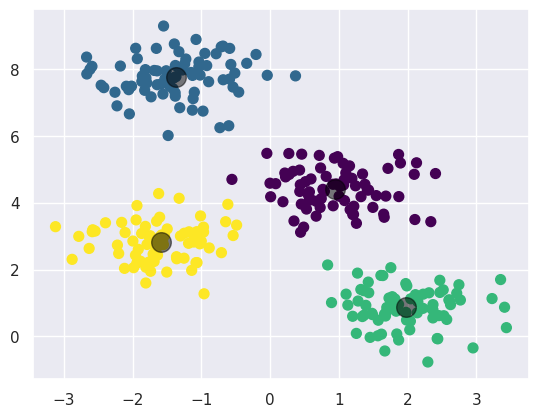

In [179]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

## Algoritma Expectation-Maximization

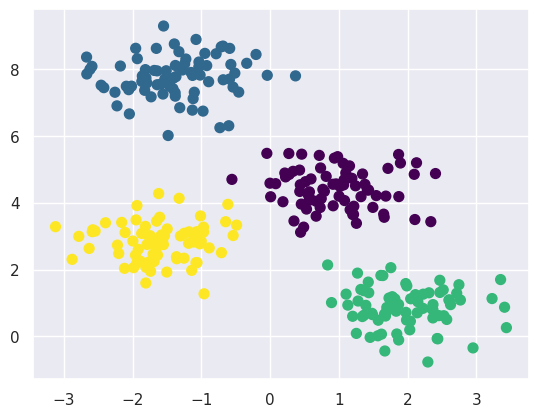

In [180]:
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):
    # 1. Randomly choose clusters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        # 2a. input label center yang baru
        labels = pairwise_distances_argmin(X, centers)

        # 2b. update center dari titik baru
        new_centers = np.array([X[labels == i].mean(0)
                                for i in range(n_clusters)])

        # 2c. cek konvergensi
        if np.all(centers == new_centers):
            break
        centers = new_centers

    return centers, labels

centers, labels = find_clusters(X, 4)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

### Perubahan random

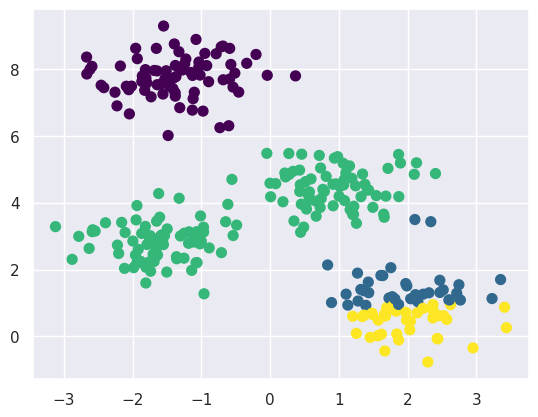

In [181]:
centers, labels = find_clusters(X, 4, rseed=0)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

### Optimalisasi Jumlah Klaster

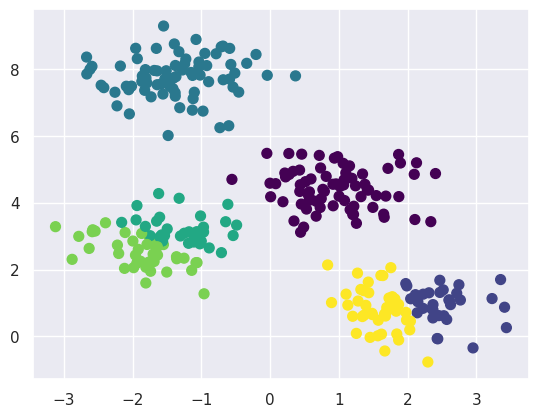

In [182]:
labels = KMeans(6, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

### Batas Klaster yang Tidak Selalu Linier

In [183]:
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)

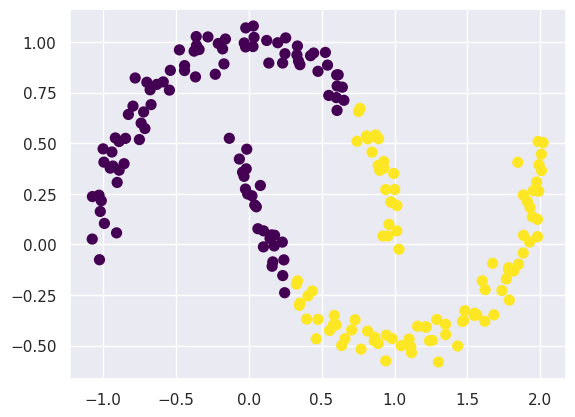

In [184]:
labels = KMeans(2, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

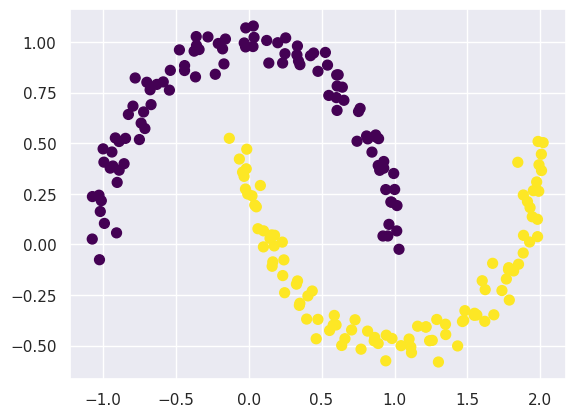

In [185]:
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                           assign_labels='kmeans')
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

## Contoh Kasus 1: Karakter Angka

In [186]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

In [187]:
# terapkan K-Means
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits.data)
kmeans.cluster_centers_.shape

(10, 64)

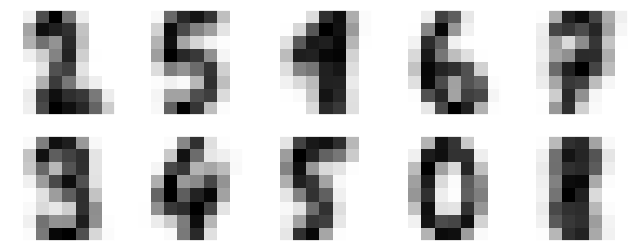

In [188]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

In [189]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

In [190]:
from sklearn.metrics import accuracy_score
accuracy_score(digits.target, labels)

0.7440178074568725

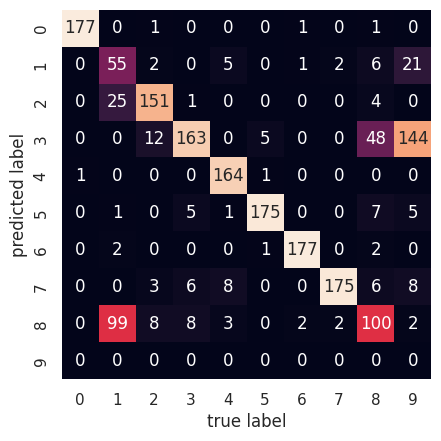

In [191]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(digits.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [192]:
from sklearn.manifold import TSNE


tsne = TSNE(n_components=2, init='random', random_state=0)
digits_proj = tsne.fit_transform(digits.data)

# hitung klaster
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits_proj)

# permutasi label
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

# hitung akurasi
accuracy_score(digits.target, labels)

0.9410127991096272

## Studi Kasus 2: Kompresi Citra

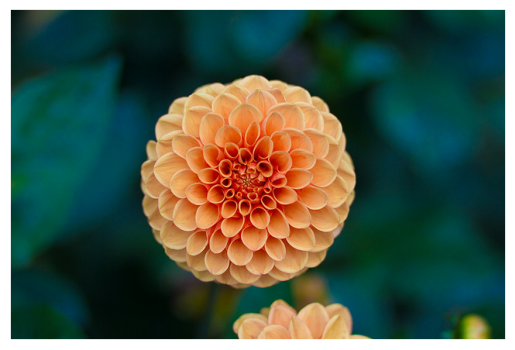

In [193]:
from sklearn.datasets import load_sample_image
flower = load_sample_image("flower.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(flower);

In [194]:
flower.shape

(427, 640, 3)

In [195]:
data = flower / 255.0
data = data.reshape(427 * 640, 3)
data.shape

(273280, 3)

In [196]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

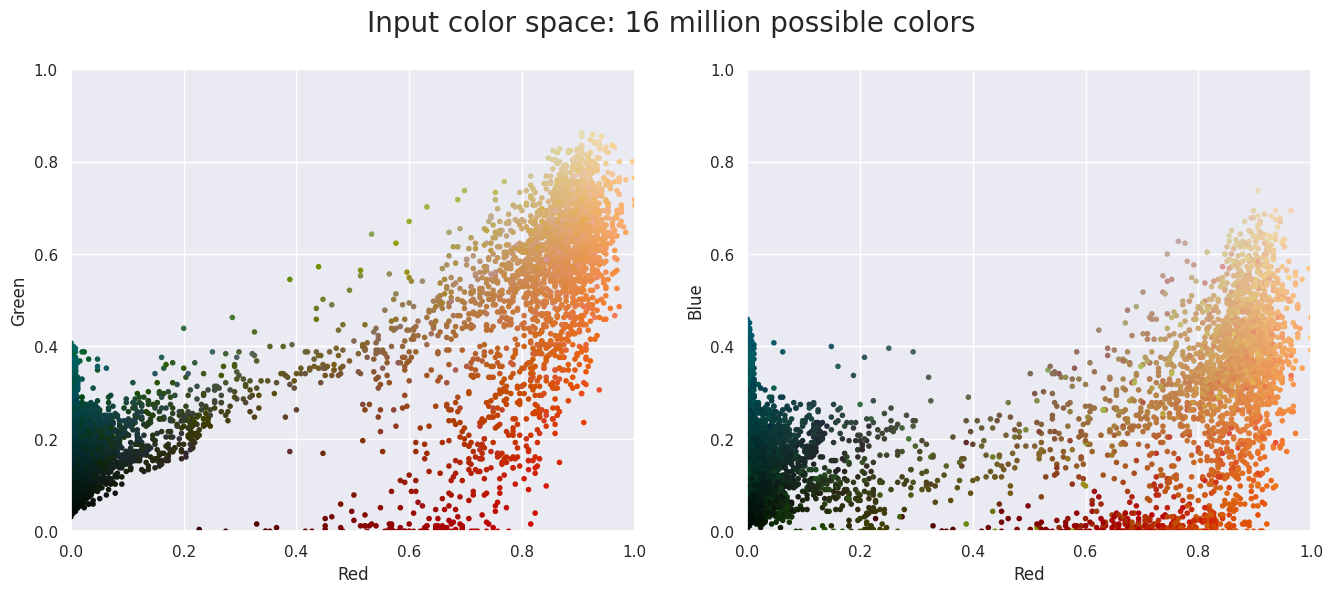

In [197]:
plot_pixels(data, title='Input color space: 16 million possible colors')

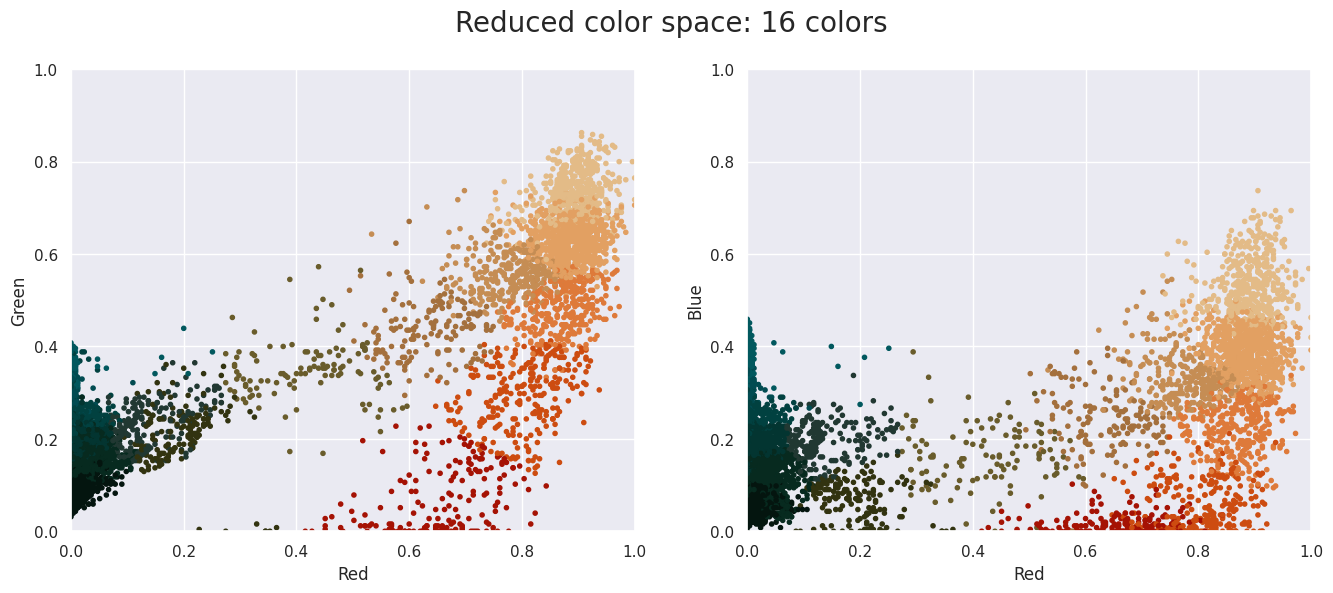

In [198]:
import warnings; warnings.simplefilter('ignore')  # Fix NumPy issues.

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,title="Reduced color space: 16 colors")

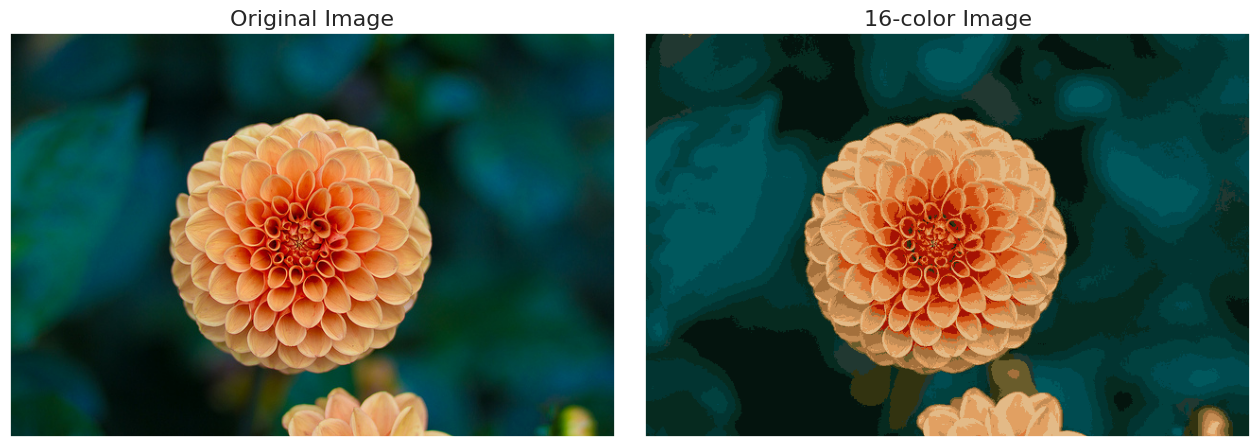

In [199]:
flower_recolored = new_colors.reshape(flower.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(flower)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(flower_recolored)
ax[1].set_title('16-color Image', size=16);

# Praktikum 3

## Pembuatan Dataset Sintetis

In [200]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]

X, labels_true = make_blobs(
    n_samples=750,
    centers=centers,
    cluster_std=0.4,
    random_state=0
)

X = StandardScaler().fit_transform(X)

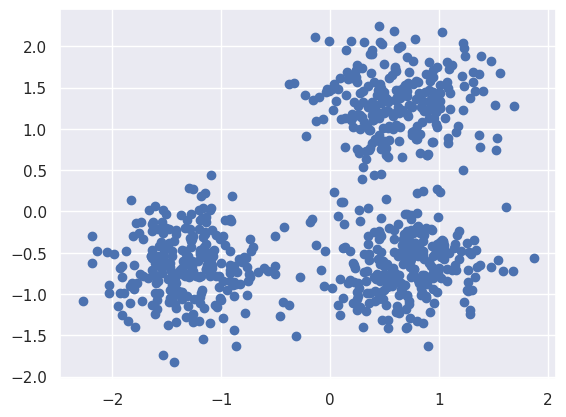

In [201]:
# Visualisasikan data
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])
plt.show()

## Compute DBSCAN

In [202]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 18


## Evaluasi Kualitas Klasterisasi

In [203]:
print("Homogeneity: %0.3f" % metrics.homogeneity_score(labels_true, labels))
print("Completeness: %0.3f" % metrics.completeness_score(labels_true, labels))
print("V-measure: %0.3f" % metrics.v_measure_score(labels_true, labels))
print("Adjusted Rand Index: %0.3f" % metrics.adjusted_rand_score(labels_true, labels))
print(
    "Adjusted Mutual Information: %0.3f"
    % metrics.adjusted_mutual_info_score(labels_true, labels)
)
print("Silhouette Coefficient: %0.3f" % metrics.silhouette_score(X, labels))

Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


## Visualisasi Hasil Klasterisasi

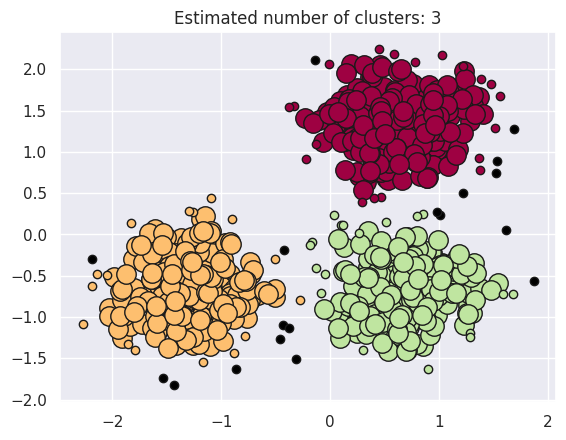

In [204]:
# Visualisasi Hasil Klasterisasi

import matplotlib.pyplot as plt
import numpy as np

# Membuat mask untuk core samples
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

# Mengambil label unik hasil DBSCAN
unique_labels = set(labels)

# Visualisasi setiap cluster
for k in unique_labels:
    if k == -1:
        # Warna hitam digunakan untuk noise
        col = [0, 0, 0, 1]
    else:
        col = plt.cm.Spectral(float(k) / n_clusters_)

    class_member_mask = labels == k

    # Core samples
    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14
    )

    # Non-core samples
    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6
    )

plt.title("Estimated number of clusters: %d" % n_clusters_)
plt.show()

# Interpretasi visual:
# Titik besar berwarna → core samples dalam klaster.
# Titik kecil berwarna → non-core samples, tetap termasuk klaster.
# Titik hitam → noise/outlier.

# Tugas Praktikum

## 1. Tugas K-Means

### Membaca Dataset Mall_Customers.csv

In [205]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [206]:
# Mengecek struktur datanya:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


### Menentukan Fitur untuk Clustering

In [207]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


Note: Fitur Annual Income (k$) dan Spending Score (1-100) dipilih karena keduanya dapat menggambarkan karakteristik pelanggan dari sisi pendapatan dan perilaku belanja.

Kenapa bukan CustomerID? Karena CustomerID hanya identitas pelanggan dan tidak menggambarkan karakteristik yang relevan untuk clustering.

Kenapa dua fitur ini juga enak digunakan? Karena hasil clustering nantinya bisa divisualisasikan secara langsung dalam grafik 2D.

### Melihat Persebaran Data

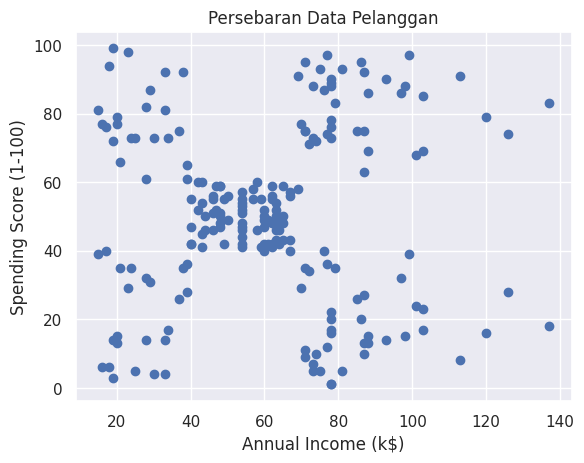

In [208]:
import matplotlib.pyplot as plt

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)']
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Persebaran Data Pelanggan')
plt.show()

Note: Visualisasi awal digunakan untuk melihat pola persebaran data sebelum dilakukan clustering.

### Menentukan Jumlah k Terbaik

In [209]:
# Menggunakan Elbow Method
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=0,
        n_init=10
    )

    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

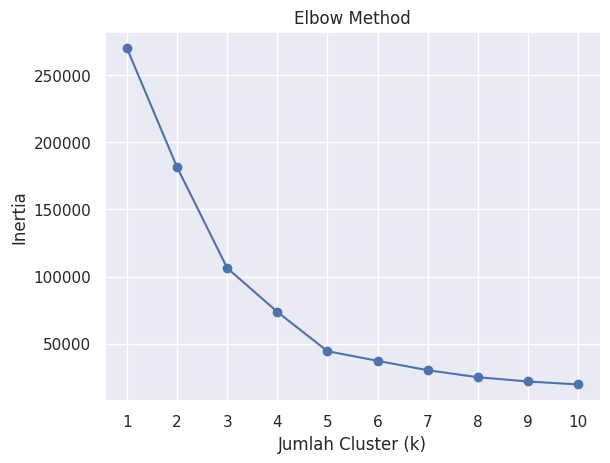

In [210]:
# Visualisasi
plt.plot(
    range(1, 11),
    inertia,
    marker='o'
)

plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(range(1, 11))
plt.show()

Note: Elbow Method digunakan untuk menentukan jumlah cluster yang sesuai dengan melihat perubahan nilai inertia. Nilai k dipilih pada titik ketika penurunan inertia yang sebelumnya besar mulai melandai, sehingga grafik membentuk pola seperti siku (elbow).

Berdasarkan grafik Elbow Method, nilai k = 5 dipilih sebagai jumlah cluster yang digunakan. Hal ini karena penurunan nilai inertia cukup signifikan dari k=1 hingga k=5, sedangkan setelah k=5 penurunannya mulai melandai. Oleh karena itu, 5 cluster dipertimbangkan sebagai jumlah cluster yang sesuai untuk model K-Means.

### Menentukan k

In [211]:
k = 5

### Membuat Model K-Means

In [212]:
kmeans = KMeans(
    n_clusters=5,
    random_state=0,
    n_init=10
)

labels = kmeans.fit_predict(X)

print(labels)

[3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3
 4 3 4 3 4 3 0 3 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 0 1 2 1 2 1 0 1 2 1 2 1 2 1 2 1 0 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1]


### Memasukkan Hasil Cluster ke Dataset

In [213]:
df['Cluster'] = labels

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,3
1,2,Male,21,15,81,4
2,3,Female,20,16,6,3
3,4,Female,23,16,77,4
4,5,Female,31,17,40,3


In [214]:
# Meluhat jumlah anggota setiap cluster
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,81
1,39
2,35
3,23
4,22


### Men-visualisasi Hasil K-Means

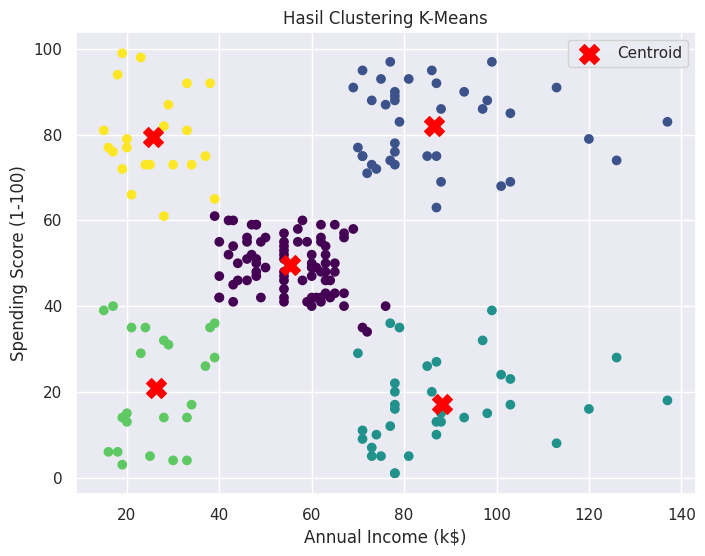

In [215]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=labels,
    cmap='viridis'
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    c='red',
    marker='X',
    label='Centroid'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Hasil Clustering K-Means')
plt.legend()

plt.show()

Note: Warna yang berbeda menunjukkan cluster pelanggan yang berbeda, sedangkan tanda X merah menunjukkan centroid atau titik pusat masing-masing cluster.



Kesimpulan: Berdasarkan hasil Elbow Method, diperoleh jumlah cluster terbaik yaitu k = 5. Pada titik tersebut, penurunan nilai inertia mulai melandai dibandingkan nilai k sebelumnya. Oleh karena itu, model K-Means menggunakan 5 cluster untuk mengelompokkan pelanggan berdasarkan fitur Annual Income (k$) dan Spending Score (1-100).

## 2. Tugas DBSCAN

### 1. Membuat dataset make_moons (1000 sampel, noise=0.05), lalu normalisasi.

Langkah 1.1 — Import library

In [216]:
# Import library untuk membuat dataset sintetis
from sklearn.datasets import make_moons

# Import StandardScaler untuk normalisasi/standardisasi data
from sklearn.preprocessing import StandardScaler

# Import matplotlib untuk visualisasi
import matplotlib.pyplot as plt

Langkah 1.2 — Membuat dataset

In [217]:
# Membuat dataset make_moons sebanyak 1000 sampel dengan noise 0.05
X, labels_true = make_moons(
    n_samples=1000,
    noise=0.05,
    random_state=0
)

# Menampilkan ukuran dataset
print("Ukuran dataset:", X.shape)

Ukuran dataset: (1000, 2)


Langkah 1.3 — Normalisasi data

In [218]:
# Melakukan standardisasi agar kedua fitur memiliki skala yang sebanding
X = StandardScaler().fit_transform(X)

# Menampilkan 5 data pertama setelah standardisasi
print(X[:5])

[[ 1.75081891  0.48393978]
 [ 1.35606443 -0.90706929]
 [-0.90150442  1.22470664]
 [-0.60117222 -0.14688373]
 [ 0.0048725  -1.28700543]]


Fungsi bagian ini: DBSCAN menentukan cluster berdasarkan jarak antar titik, sehingga skala fitur perlu dibuat sebanding agar satu fitur tidak mendominasi perhitungan jarak.

Langkah 1.4 — Visualisasi dataset

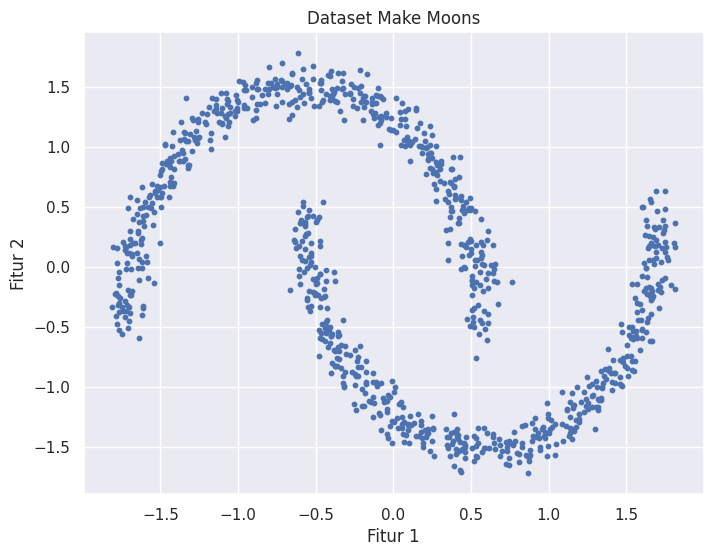

In [219]:
# Membuat scatter plot dataset make_moons
plt.figure(figsize=(8, 6))

# X[:, 0] = fitur pertama dan X[:, 1] = fitur kedua
plt.scatter(X[:, 0], X[:, 1], s=10)

# Memberikan judul pada grafik
plt.title('Dataset Make Moons')

# Memberikan nama sumbu
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')

# Menampilkan grafik
plt.show()

### 2. Menjalankan DBSCAN dengan eps=0.2, min_samples=5, hitung jumlah klaster & noise.

Langkah 2.1 — Membuat model DBSCAN

In [220]:
# Import algoritma DBSCAN
from sklearn.cluster import DBSCAN

# Membuat dan menjalankan DBSCAN
db = DBSCAN(
    eps=0.2,
    min_samples=5
).fit(X)

# Mengambil label cluster hasil DBSCAN
labels = db.labels_

Langkah 2.2 — Menghitung jumlah cluster dan noise

In [221]:
# Menghitung jumlah cluster dan mengabaikan label -1 (noise)
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

# Menghitung jumlah titik yang memiliki label -1
n_noise_ = list(labels).count(-1)

# Menampilkan hasil
print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 2
Estimated number of noise points: 0


### 3. Meng-evaluasi dengan metrik: Homogeneity, Completeness, V-measure, ARI, AMI, Silhouette.

Langkah 3.1 — Import metrics

In [222]:
# Import metrics untuk mengevaluasi hasil clustering
from sklearn import metrics

Langkah 3.2 — Menghitung metrik evaluasi

In [223]:
# Mengukur apakah setiap cluster hanya berisi anggota dari kelas yang sama
homogeneity = metrics.homogeneity_score(labels_true, labels)

# Mengukur apakah anggota kelas yang sama berada pada cluster yang sama
completeness = metrics.completeness_score(labels_true, labels)

# Kombinasi antara Homogeneity dan Completeness
v_measure = metrics.v_measure_score(labels_true, labels)

# Mengukur kesamaan antara hasil clustering dan label asli
ari = metrics.adjusted_rand_score(labels_true, labels)

# Mengukur kesamaan informasi antara hasil clustering dan label asli
ami = metrics.adjusted_mutual_info_score(labels_true, labels)

# Mengukur seberapa rapat dan terpisah cluster yang terbentuk
silhouette = metrics.silhouette_score(X, labels)

# Menampilkan hasil evaluasi
print("Homogeneity: %0.3f" % homogeneity)
print("Completeness: %0.3f" % completeness)
print("V-measure: %0.3f" % v_measure)
print("Adjusted Rand Index: %0.3f" % ari)
print("Adjusted Mutual Information: %0.3f" % ami)
print("Silhouette Coefficient: %0.3f" % silhouette)

Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
Adjusted Rand Index: 1.000
Adjusted Mutual Information: 1.000
Silhouette Coefficient: 0.392


### 4. Mem-visualisasikan hasil DBSCAN (core sample = titik besar, non-core = titik kecil, noise = hitam).

Langkah 4.1 — Menentukan core sample

In [224]:
# Import numpy
import numpy as np

# Membuat array boolean untuk menandai core sample
core_samples_mask = np.zeros_like(labels, dtype=bool)

# Posisi core sample diubah menjadi True
core_samples_mask[db.core_sample_indices_] = True

# Mengambil semua label cluster yang unik
unique_labels = set(labels)

Langkah 4.2 — Visualisasi

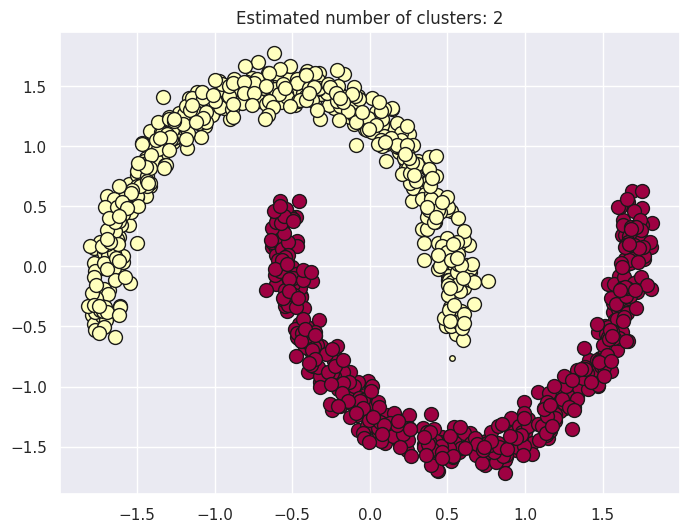

In [225]:
# Membuat area grafik
plt.figure(figsize=(8, 6))

# Melakukan perulangan untuk setiap cluster
for k in unique_labels:

    # Jika label -1, titik merupakan noise dan diberi warna hitam
    if k == -1:
        col = [0, 0, 0, 1]
    else:
        # Cluster selain noise mendapatkan warna yang berbeda
        col = plt.cm.Spectral(float(k) / n_clusters_)

    # Menentukan data yang termasuk cluster k
    class_member_mask = labels == k

    # Mengambil core sample pada cluster k
    xy = X[class_member_mask & core_samples_mask]

    # Core sample digambar dengan ukuran besar
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        'o',
        markerfacecolor=tuple(col),
        markeredgecolor='k',
        markersize=10
    )

    # Mengambil non-core sample pada cluster k
    xy = X[class_member_mask & ~core_samples_mask]

    # Non-core sample digambar dengan ukuran kecil
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        'o',
        markerfacecolor=tuple(col),
        markeredgecolor='k',
        markersize=4
    )

# Memberikan judul grafik
plt.title('Estimated number of clusters: %d' % n_clusters_)

# Menampilkan grafik
plt.show()

### 5. Melakukan eksperimen:
    eps = 0.05, 0.1, 0.3, 0.5
    min_samples = 3, 10, 20
    Mencatat perubahan klaster, noise, dan kualitas evaluasi.

Langkah 5.1 — Menentukan parameter

In [226]:
# Daftar nilai eps yang akan diuji
eps_values = [0.05, 0.1, 0.3, 0.5]

# Daftar nilai min_samples yang akan diuji
min_samples_values = [3, 10, 20]

Langkah 5.2 — Menjalankan semua kombinasi

In [227]:
# List untuk menyimpan seluruh hasil eksperimen
results = []

# Mencoba setiap nilai eps
for eps in eps_values:

    # Mencoba setiap nilai min_samples
    for min_samples in min_samples_values:

        # Membuat model DBSCAN berdasarkan parameter yang sedang diuji
        db_exp = DBSCAN(
            eps=eps,
            min_samples=min_samples
        ).fit(X)

        # Mengambil label hasil clustering
        labels_exp = db_exp.labels_

        # Menghitung jumlah cluster
        n_clusters = len(set(labels_exp)) - (
            1 if -1 in labels_exp else 0
        )

        # Menghitung jumlah noise
        n_noise = list(labels_exp).count(-1)

        # Menghitung metrik evaluasi
        homogeneity = metrics.homogeneity_score(
            labels_true, labels_exp
        )

        completeness = metrics.completeness_score(
            labels_true, labels_exp
        )

        v_measure = metrics.v_measure_score(
            labels_true, labels_exp
        )

        ari = metrics.adjusted_rand_score(
            labels_true, labels_exp
        )

        ami = metrics.adjusted_mutual_info_score(
            labels_true, labels_exp
        )

        # Silhouette hanya dapat dihitung jika cluster yang terbentuk > 1
        if n_clusters > 1:
            silhouette = metrics.silhouette_score(
                X, labels_exp
            )
        else:
            silhouette = np.nan

        # Menyimpan hasil eksperimen
        results.append([
            eps,
            min_samples,
            n_clusters,
            n_noise,
            homogeneity,
            completeness,
            v_measure,
            ari,
            ami,
            silhouette
        ])

Langkah 5.3 — Membuat tabel hasil eksperimen

In [228]:
# Mengubah hasil eksperimen menjadi DataFrame
results_df = pd.DataFrame(
    results,
    columns=[
        'eps',
        'min_samples',
        'Jumlah Cluster',
        'Jumlah Noise',
        'Homogeneity',
        'Completeness',
        'V-measure',
        'ARI',
        'AMI',
        'Silhouette'
    ]
)

# Menampilkan seluruh hasil eksperimen
results_df

,eps,min_samples,Jumlah Cluster,Jumlah Noise,Homogeneity,Completeness,V-measure,ARI,AMI,Silhouette
0,0.05,3,67,197,0.803825,0.154915,0.259767,0.032984,0.246428,0.077967
1,0.05,10,0,1000,0.000000,1.000000,0.000000,0.000000,0.000000,NaN
2,0.05,20,0,1000,0.000000,1.000000,0.000000,0.000000,0.000000,NaN
3,0.10,3,3,18,0.983471,0.708395,0.823571,0.854285,0.823246,0.137887
4,0.10,10,9,63,0.938949,0.358282,0.518656,0.435052,0.516899,0.184140
5,0.10,20,6,844,0.157108,0.153385,0.155224,0.010402,0.151519,-0.409118
6,0.30,3,2,0,1.000000,1.000000,1.000000,1.000000,1.000000,0.391597
7,0.30,10,2,0,1.000000,1.000000,1.000000,1.000000,1.000000,0.391597
8,0.30,20,2,0,1.000000,1.000000,1.000000,1.000000,1.000000,0.391597
9,0.50,3,1,0,0.000000,1.000000,0.000000,0.000000,0.000000,NaN


Berdasarkan hasil eksperimen, parameter eps = 0.3 menghasilkan kualitas clustering yang sangat baik untuk min_samples = 3, 10, maupun 20. DBSCAN berhasil membentuk 2 cluster tanpa noise. Nilai Homogeneity, Completeness, V-measure, ARI, dan AMI masing-masing sebesar 1.000, yang menunjukkan bahwa hasil clustering sesuai dengan label asli dataset make_moons. Nilai Silhouette sebesar 0.391597 menunjukkan tingkat pemisahan cluster berdasarkan jarak, namun nilai tersebut perlu dipahami dalam konteks bentuk non-konveks dari dataset make_moons.